Ths code runs the functions.py file


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import ot

import functions as fct  # your custom module: ScoreNet, ScoreNet3, train_score_net, etc.

# Single device definition, reused everywhere below — avoids redefining
# identically in multiple cells.
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

Using device: mps


theta_hat (SGLD estimate of mu): [ 1.99937541 -1.99038508]
True mu:                         [ 2 -2]


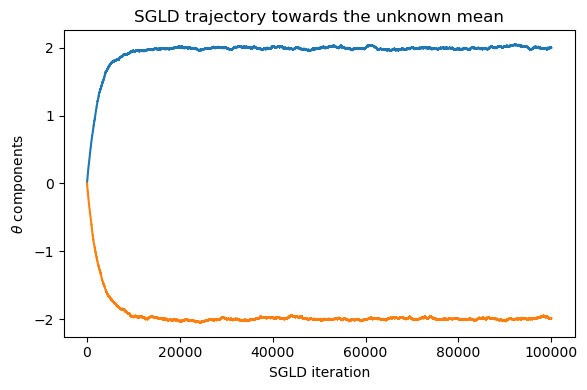

In [9]:
d = 2
mu_unknown = np.array([2, -2])
sigma_known = np.array([1, 1])

N = 100_000
X_data_normal = np.random.normal(mu_unknown, sigma_known, (N, d))

# SGLD hyperparameters
theta_0 = np.zeros(d)
beta = 1e6       # inverse temperature - large beta -> SGLD behaves close to SGD
lambda_ = 0.001  # step size
N_sgld = 100_000
t_0_sgld = 0
T_sgld = 1

theta_hat, theta_tracker = fct.thetahat_func(
    X_data=X_data_normal, beta=beta, lambda_=lambda_,
    theta_0=theta_0, N_sgld=N_sgld, t_0=t_0_sgld, T=T_sgld
)

print("theta_hat (SGLD estimate of mu):", theta_hat)
print("True mu:                        ", mu_unknown)

plt.figure(figsize=(6, 4))
plt.plot(theta_tracker)
plt.xlabel("SGLD iteration")
plt.ylabel(r"$\theta$ components")
plt.title("SGLD trajectory towards the unknown mean")
plt.tight_layout()
plt.show()

Single sample: [ 2.30088427 -1.30231302]


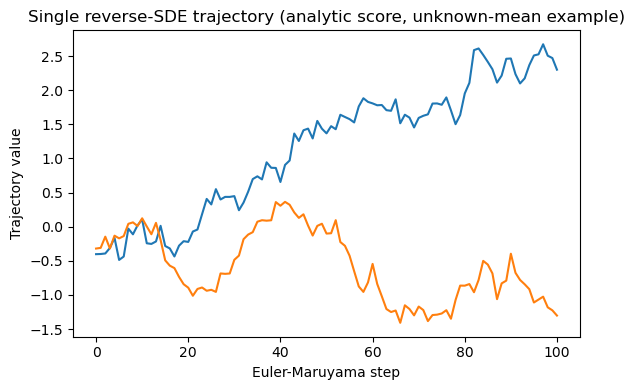

In [10]:
# ------------------------------------------------------------
# Single-trajectory check: plug theta_hat into the analytic-score
# reverse SDE and confirm the path looks sensible.
# ------------------------------------------------------------
sample, path = fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.01, T=1, d=2)
print("Single sample:", sample)

plt.figure(figsize=(6, 4))
plt.plot(path)
plt.xlabel("Euler-Maruyama step")
plt.ylabel("Trajectory value")
plt.title("Single reverse-SDE trajectory (analytic score, unknown-mean example)")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Distributional check: many independent reverse-SDE draws should
# concentrate near mu_unknown, since theta_hat approx. mu_unknown.
# ------------------------------------------------------------
N_samples = 10_000
samples_analytic = np.array([
    fct.euler_maruyama_sample(theta_hat=theta_hat, gamma=0.001, T=1, d=2)[0]
    for _ in range(N_samples)
])

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_analytic[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Samples from the analytic-score reverse SDE (unknown-mean example)")
plt.tight_layout()
plt.show()

In [ ]:
D_1_normal = 32
net_normal = fct.ScoreNet(d=d, D_1=D_1_normal)

net_normal = fct.train_score_net(
    net_normal, X_data_normal, t_0=0, T=1, d=d,
    n_iters=5000, batch_size=256, lr=1e-3, device=device
)

samples_nn_normal = fct.euler_maruyama_sample_nn_batch(
    net_normal, gamma=0.001, T=1, d=d, N_samples=100_000, device=device
)

print("NN sample mean:", samples_nn_normal.mean(axis=0))
print("True mu:       ", mu_unknown)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_nn_normal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("NN-based reverse SDE samples (unimodal sanity check)")
plt.tight_layout()
plt.show()

NameError: name 'X_data_normal' is not defined

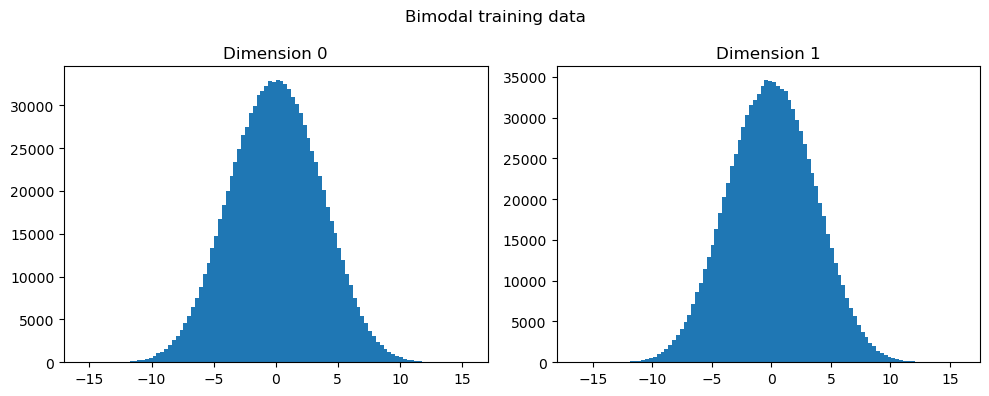

In [ ]:
d = 2
mu1 = np.array([2.0, 2.0])
mu2 = np.array([-2.0, -2.0])
weight = 0.5
sigma_mix = 3.0

N_bimodal = 1_000_000
X_data_bimodal = fct.sample_bimodal_data(
    N=N_bimodal, d=d, mu1=mu1, mu2=mu2, sigma=sigma_mix, weight=weight
)

true_mixture_mean = weight * mu1 + (1 - weight) * mu2

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(X_data_bimodal[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal training data (ground truth $\\pi_D$)")
plt.tight_layout()
plt.show()

iter 0, loss = 3.6644
iter 500, loss = 3.8231
iter 1000, loss = 4.0154
iter 1500, loss = 3.4588
iter 2000, loss = 3.0775
iter 2500, loss = 3.1832
iter 3000, loss = 3.1411
iter 3500, loss = 2.7129
iter 4000, loss = 2.5386
iter 4500, loss = 3.7521
iter 5000, loss = 4.9542
iter 5500, loss = 3.0150
iter 6000, loss = 3.2370
iter 6500, loss = 4.1305
iter 7000, loss = 3.2383
iter 7500, loss = 5.3645
iter 8000, loss = 3.7112
iter 8500, loss = 2.2864
iter 9000, loss = 3.4267
iter 9500, loss = 3.4134
NN sample mean:     [-0.1178598   0.11640637]
True mixture mean:  [0. 0.]


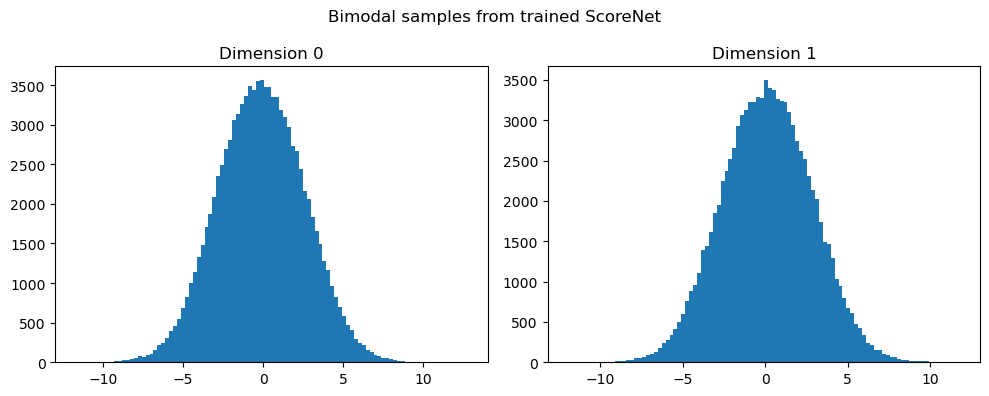

In [ ]:
# ------------------------------------------------------------
# Train the 2-layer ScoreNet on the bimodal mixture at T = 1.
# ------------------------------------------------------------
D_1_bimodal = 128

net_bimodal = fct.ScoreNet(d=d, D_1=D_1_bimodal)
net_bimodal = fct.train_score_net(
    net_bimodal, X_data_bimodal, t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3, device=device
)

samples_bimodal_2layer = fct.euler_maruyama_sample_nn_batch(
    net_bimodal, gamma=0.001, T=1, d=d, N_samples=100_000, device=device
)

print("2-layer NN sample mean:", samples_bimodal_2layer.mean(axis=0))
print("True mixture mean:     ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal_2layer[:, i], bins=100)
    axes[i].set_title(f"Dimension {i}")
plt.suptitle("Bimodal samples from trained 2-layer ScoreNet (T=1)")
plt.tight_layout()
plt.show()

iter 0, loss = 3.2496
iter 500, loss = 2.9314
iter 1000, loss = 3.8273
iter 1500, loss = 3.6478
iter 2000, loss = 4.4322
iter 2500, loss = 4.1825
iter 3000, loss = 3.0530
iter 3500, loss = 4.1630
iter 4000, loss = 3.0241
iter 4500, loss = 3.9168
iter 5000, loss = 3.0000
iter 5500, loss = 3.7646
iter 6000, loss = 4.1389
iter 6500, loss = 3.2642
iter 7000, loss = 4.5705
iter 7500, loss = 4.0158
iter 8000, loss = 4.2908
iter 8500, loss = 3.3774
iter 9000, loss = 2.7863
iter 9500, loss = 3.4197
3-layer NN sample mean:     [-0.06374154 -0.14919567]
True mixture mean:          [0. 0.]


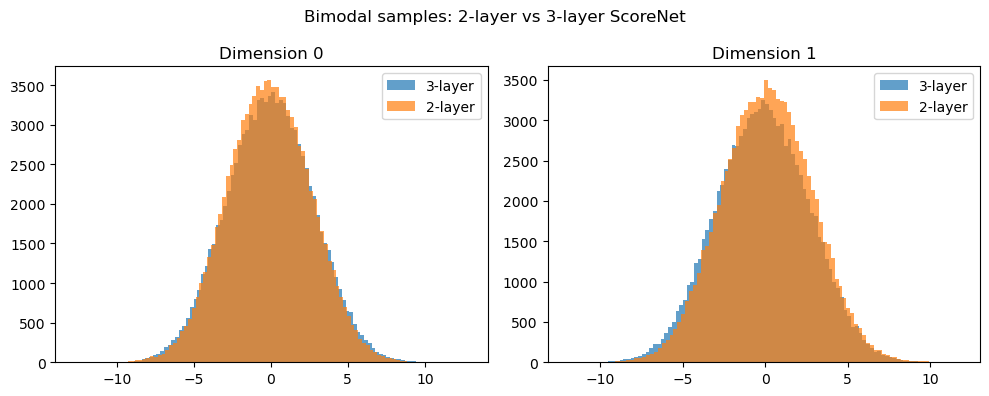

In [ ]:
# ------------------------------------------------------------
# Train ScoreNet3 (3-layer) on the same data, for direct comparison.
# ------------------------------------------------------------
D_1_bimodal_3 = 128
D_2_bimodal_3 = 128

net_bimodal_3 = fct.ScoreNet3(d=d, D_1=D_1_bimodal_3, D_2=D_2_bimodal_3)
net_bimodal_3 = fct.train_score_net(
    net_bimodal_3, X_data_bimodal, t_0=1e-3, T=1, d=d,
    n_iters=10_000, batch_size=512, lr=1e-3, device=device
)

samples_bimodal_3layer = fct.euler_maruyama_sample_nn_batch(
    net_bimodal_3, gamma=0.001, T=1, d=d, N_samples=100_000, device=device
)

print("3-layer NN sample mean:", samples_bimodal_3layer.mean(axis=0))
print("True mixture mean:     ", true_mixture_mean)

fig, axes = plt.subplots(1, d, figsize=(10, 4))
for i in range(d):
    axes[i].hist(samples_bimodal_3layer[:, i], bins=100, alpha=0.7, label="3-layer")
    axes[i].hist(samples_bimodal_2layer[:, i], bins=100, alpha=0.7, label="2-layer")
    axes[i].set_title(f"Dimension {i}")
    axes[i].legend()
plt.suptitle("Bimodal samples: 2-layer vs 3-layer ScoreNet (T=1)")
plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------
# Quick numerical sanity check on the mixture parameters vs the data.
# ------------------------------------------------------------
print("mu1:", mu1, " mu2:", mu2, " weight:", weight)
print("X_data_bimodal mean per dim:", X_data_bimodal.mean(axis=0))
print("X_data_bimodal std per dim: ", X_data_bimodal.std(axis=0))

mu1: [2. 2.] mu2: [-2. -2.]
weight: 0.5
X_data_bimodal mean per dim: [0.00664818 0.00159826]
X_data_bimodal std per dim:  [3.6091537  3.60441301]


In [ ]:
N_w2_snapshot = 5000

# NOTE: for a strictly clean train/eval split, draw a fresh independent
# batch via fct.sample_bimodal_data(...) instead of slicing X_data_bimodal,
# since the networks above trained on random indices from the full array.
samples_true_snapshot = X_data_bimodal[:N_w2_snapshot]
samples_2layer_snapshot = samples_bimodal_2layer[:N_w2_snapshot]
samples_3layer_snapshot = samples_bimodal_3layer[:N_w2_snapshot]

a = np.ones(N_w2_snapshot) / N_w2_snapshot
b = np.ones(N_w2_snapshot) / N_w2_snapshot

M_2layer = ot.dist(samples_2layer_snapshot, samples_true_snapshot, metric='sqeuclidean')
M_3layer = ot.dist(samples_3layer_snapshot, samples_true_snapshot, metric='sqeuclidean')

W2_2layer_snapshot = np.sqrt(ot.emd2(a, b, M_2layer, numItermax=1_000_000))
W2_3layer_snapshot = np.sqrt(ot.emd2(a, b, M_3layer, numItermax=1_000_000))

print(f"W2 (2-layer ScoreNet, N={N_w2_snapshot}): {W2_2layer_snapshot:.4f}")
print(f"W2 (3-layer ScoreNet, N={N_w2_snapshot}): {W2_3layer_snapshot:.4f}")

W2 (2-layer ScoreNet): 1.3979
W2 (3-layer ScoreNet): 1.2496


Checkpoint 1000...
  W2 2-layer: 1.2348 ± 0.0000 | W2 3-layer: 1.3213 ± 0.0000
Checkpoint 2000...
  W2 2-layer: 1.2426 ± 0.0000 | W2 3-layer: 1.3303 ± 0.0000
Checkpoint 5000...
  W2 2-layer: 1.3909 ± 0.0000 | W2 3-layer: 1.2929 ± 0.0000
Checkpoint 10000...
  W2 2-layer: 1.3770 ± 0.0000 | W2 3-layer: 1.1263 ± 0.0000
Checkpoint 20000...
  W2 2-layer: 1.1429 ± 0.0000 | W2 3-layer: 1.2850 ± 0.0000


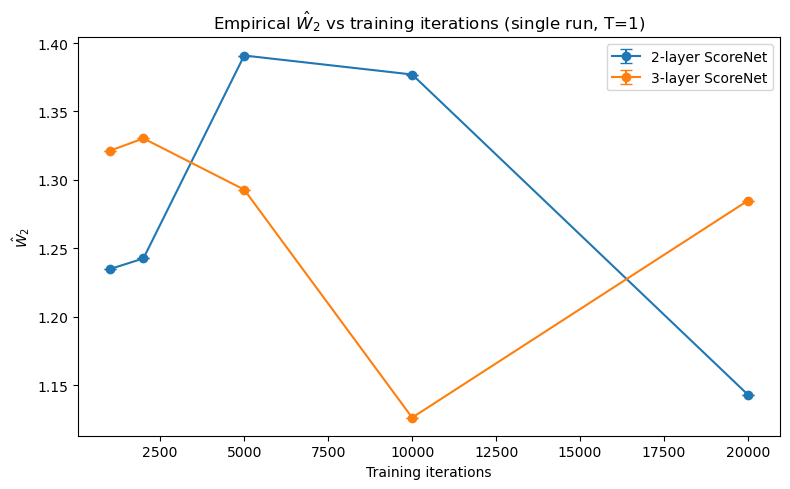

In [ ]:
# ------------------------------------------------------------
# Noise floor at a single N: W_2 between two INDEPENDENT samples both
# drawn from pi_D. Not zero at finite N - this is the estimator's own bias.
# ------------------------------------------------------------
N_floor_check = 5000
samples_true_a = X_data_bimodal[:N_floor_check]
samples_true_b = X_data_bimodal[N_floor_check:2 * N_floor_check]

a = np.ones(N_floor_check) / N_floor_check
b = np.ones(N_floor_check) / N_floor_check

M_floor = ot.dist(samples_true_a, samples_true_b, metric='sqeuclidean')
W2_floor_5000 = np.sqrt(ot.emd2(a, b, M_floor, numItermax=1_000_000))
print(f"W2 between two independent samples of pi_D (N={N_floor_check}): {W2_floor_5000:.4f}")

i find that the curves for both the 3 layer neural net and the 2 layer neural net in non monotone decreasing. This means that there could be a computational ceiling on how well this implementation fits the data. 

Checkpoint 1000...
  W2 2-layer: 1.4542 ± 0.0336 | W2 3-layer: 1.2978 ± 0.0265
Checkpoint 2000...
  W2 2-layer: 1.3609 ± 0.0600 | W2 3-layer: 1.3141 ± 0.0557
Checkpoint 5000...
  W2 2-layer: 1.3480 ± 0.0290 | W2 3-layer: 1.2236 ± 0.0291
Checkpoint 10000...
  W2 2-layer: 1.3067 ± 0.0110 | W2 3-layer: 1.2213 ± 0.0477
Checkpoint 20000...
  W2 2-layer: 1.3381 ± 0.0452 | W2 3-layer: 1.2268 ± 0.0239


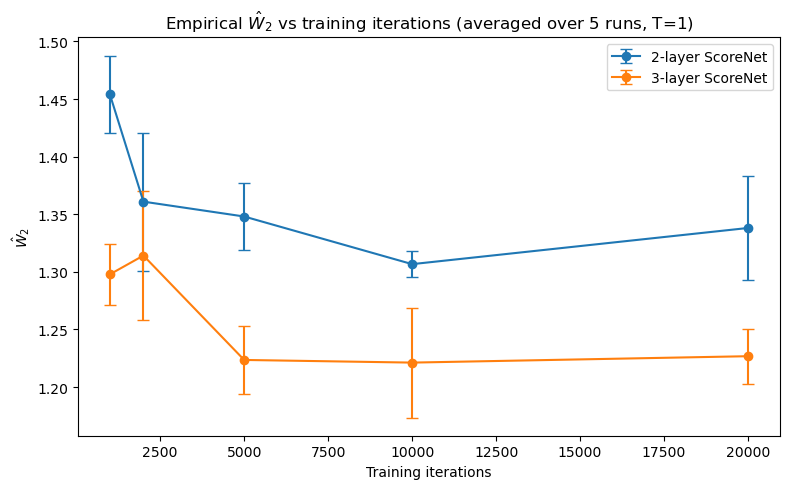

In [ ]:
# ------------------------------------------------------------
# Noise floor as a function of N. Lets us look up the floor at whatever
# N we use later (e.g. N=2000 in the T-sweep, Section 6).
# ------------------------------------------------------------
def W2_self_floor(X_data, N, n_repeats=5):
    """
    Estimate the W_2 noise floor at sample size N by computing W_2
    between two independent draws from X_data, averaged over n_repeats
    to reduce Monte Carlo variance in the estimate itself.
    """
    W2_vals = []
    a = np.ones(N) / N
    b = np.ones(N) / N
    for _ in range(n_repeats):
        idx = np.random.permutation(len(X_data))
        s1 = X_data[idx[:N]]
        s2 = X_data[idx[N:2 * N]]
        M = ot.dist(s1, s2, metric='sqeuclidean')
        W2_vals.append(np.sqrt(ot.emd2(a, b, M, numItermax=10_000_000)))
    return np.mean(W2_vals), np.std(W2_vals)


sample_sizes = [500, 1000, 2000, 3000, 5000, 10000]
floors, floor_stds = [], []

for N in sample_sizes:
    mean, std = W2_self_floor(X_data_bimodal, N, n_repeats=5)
    floors.append(mean)
    floor_stds.append(std)
    print(f"N = {N:5d}: noise floor = {mean:.4f} ± {std:.4f}")

W2_floor_by_N = dict(zip(sample_sizes, floors))  # lookup table for later sections

plt.figure(figsize=(8, 5))
plt.errorbar(sample_sizes, floors, yerr=floor_stds, marker='o', capsize=4)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Sample size $N$')
plt.ylabel(r'$\hat{W}_2$ noise floor')
plt.title(r'Empirical $\hat{W}_2$ between two independent samples of $\pi_D$')
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

We cannot improve the distance between the distribution here by increasing the number training iterations. THe $\epsilon_{SN}$ is the error of the network estimated score. 


$$\varepsilon_{SN} = \int_\epsilon^T \frac{\kappa(t)}{T - \epsilon} \int_{\mathbb{R}^d} \bigl|\nabla_x \log p_t(x) - s(t, \hat{\theta}, x)\bigr|^2 p_t(x)\, dx\, dt.$$

iter 0, loss = 4.1554
T = 1: W2 = 1.2077 ± 0.0297
iter 0, loss = 3.8405
T = 1.5: W2 = 0.6053 ± 0.0166
iter 0, loss = 2.1523
T = 1.75: W2 = 0.5678 ± 0.0030
iter 0, loss = 2.2350
T = 2: W2 = 0.5702 ± 0.0450
iter 0, loss = 1.8616
T = 2.5: W2 = 0.5502 ± 0.0317
iter 0, loss = 1.5995
T = 3: W2 = 0.5726 ± 0.0608
iter 0, loss = 1.5694
T = 4: W2 = 0.9153 ± 0.0419
iter 0, loss = 1.4538
T = 5: W2 = 0.9909 ± 0.5223
iter 0, loss = 1.3073
T = 10: W2 = 0.7354 ± 0.0208


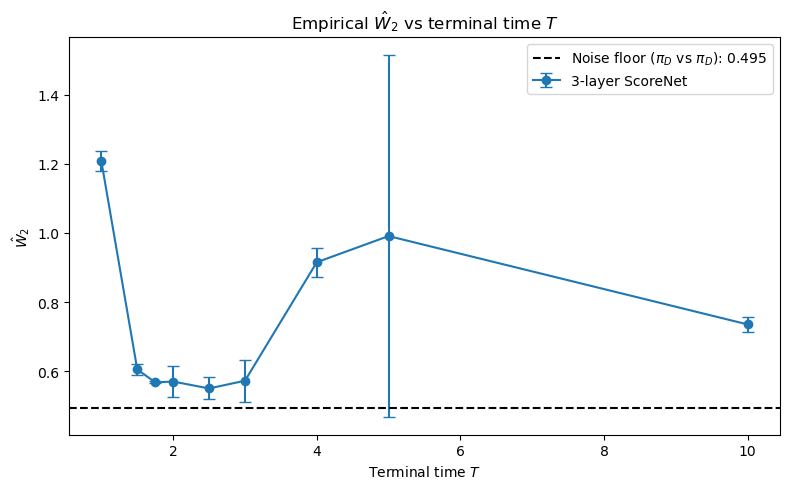

In [ ]:
checkpoints = [100, 250, 500, 1000, 2000, 5000, 10000, 20000]

# Quick single-run sanity check before the expensive multi-repeat version.
results_T1_single = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=1, T=1
)
fct.plot_W2_curve(results_T1_single, title_suffix="(single run, T=1)")

This reduction in loss can be explained by the $C_2$ term in the error bound. 

$e^{-2\hat{L}_{\mathrm{MO}}(T - \epsilon) - \epsilon}$

The larger T increases the negative exponent on the exponential multiplying the bound on $C_2$ constant. It seems as though there is a sweetspot for the choice of T.  

Checkpoint 1000...
  W2 2-layer: 1.1928 ± 0.0281 | W2 3-layer: 0.7060 ± 0.0313
Checkpoint 2000...
  W2 2-layer: 0.7507 ± 0.0259 | W2 3-layer: 0.8210 ± 0.0564
Checkpoint 5000...
  W2 2-layer: 0.7357 ± 0.0932 | W2 3-layer: 0.7374 ± 0.0469
Checkpoint 10000...
  W2 2-layer: 0.6015 ± 0.0313 | W2 3-layer: 0.6063 ± 0.0371
Checkpoint 20000...
  W2 2-layer: 0.6862 ± 0.0513 | W2 3-layer: 0.7570 ± 0.0437


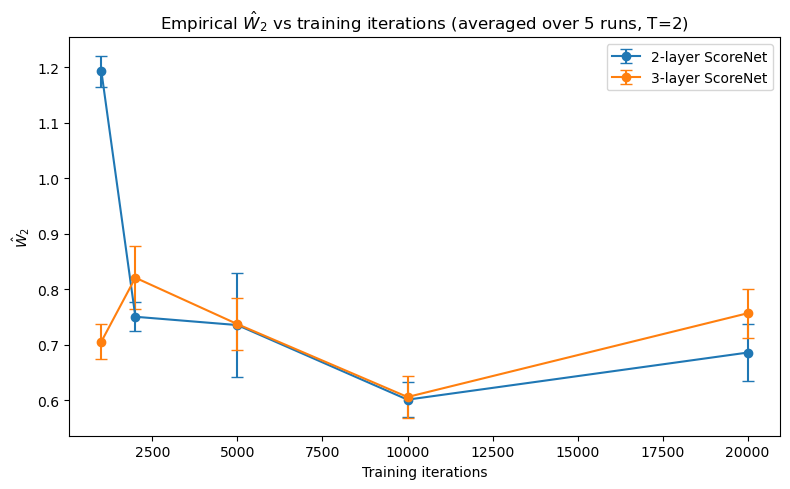

In [ ]:
# Averaged (5 repeats), T=1: expect a plateau once initialisation error dominates.
results_T1 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=1
)
fct.plot_W2_curve(results_T1, title_suffix="(averaged over 5 runs, T=1)")

Checkpoint 1000...
  W2 2-layer: 2.0543 ± 0.2349 | W2 3-layer: 1.2568 ± 0.0982
Checkpoint 2000...
  W2 2-layer: 0.8386 ± 0.0919 | W2 3-layer: 0.8779 ± 0.0289
Checkpoint 5000...
  W2 2-layer: 0.7806 ± 0.0876 | W2 3-layer: 0.8537 ± 0.0276
Checkpoint 10000...
  W2 2-layer: 0.6664 ± 0.0225 | W2 3-layer: 0.6243 ± 0.0455
Checkpoint 20000...
  W2 2-layer: 0.6906 ± 0.0667 | W2 3-layer: 0.5752 ± 0.0444


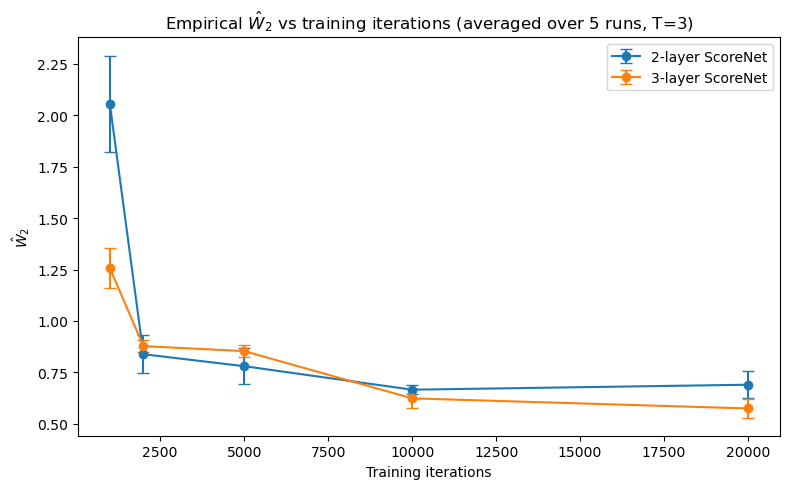

In [ ]:
# T=2: term 2 (initialisation error) decays in T, so expect a lower floor than T=1.
results_T2 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2
)
fct.plot_W2_curve(results_T2, title_suffix="(averaged over 5 runs, T=2)")

In [ ]:
# T=3, default N_w2. Kept distinct from the N_w2=10000 version in Section 7.
results_T3 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3
)
fct.plot_W2_curve(results_T3, title_suffix="(averaged over 5 runs, T=3)")

W2 between two independent samples of pi_D (N=5000): 0.3708


In [ ]:
results_T3_N10000 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3, N_w2=10_000
)
fct.plot_W2_curve(results_T3_N10000, title_suffix="(averaged over 5 runs, T=3, N_w2=10000)")

N =   500: noise floor = 0.9645 ± 0.0750
N =  1000: noise floor = 0.6808 ± 0.0761
N =  2000: noise floor = 0.5017 ± 0.0247
N =  3000: noise floor = 0.4281 ± 0.0185
N =  5000: noise floor = 0.3371 ± 0.0193
N = 10000: noise floor = 0.2513 ± 0.0097


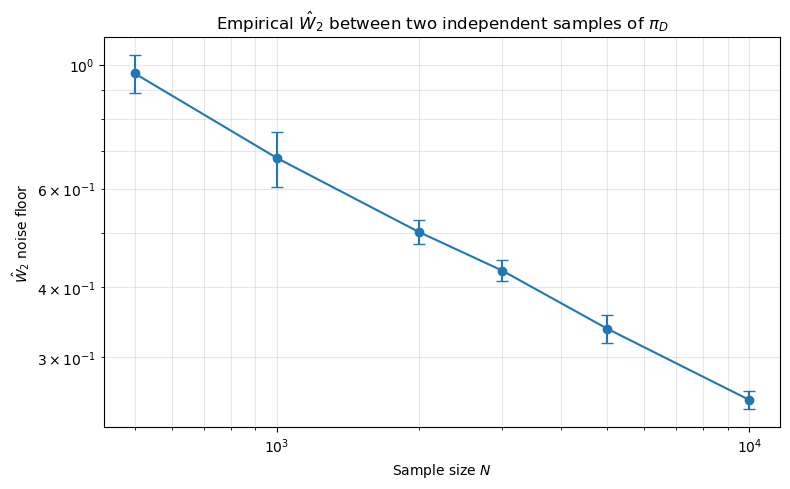

In [ ]:
results_T2_N10000 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2, N_w2=10_000
)
fct.plot_W2_curve(results_T2_N10000, title_suffix="(averaged over 5 runs, T=2, N_w2=10000)")

Checkpoint 1000...
  W2 2-layer: 1.9840 ± 0.0834 | W2 3-layer: 1.4757 ± 0.0339
Checkpoint 2000...
  W2 2-layer: 0.8042 ± 0.0188 | W2 3-layer: 0.7106 ± 0.0292
Checkpoint 5000...
  W2 2-layer: 0.5727 ± 0.0100 | W2 3-layer: 0.7034 ± 0.0259
Checkpoint 10000...
  W2 2-layer: 0.4680 ± 0.0381 | W2 3-layer: 0.5026 ± 0.0322
Checkpoint 20000...
  W2 2-layer: 0.7586 ± 0.0394 | W2 3-layer: 0.4650 ± 0.0217


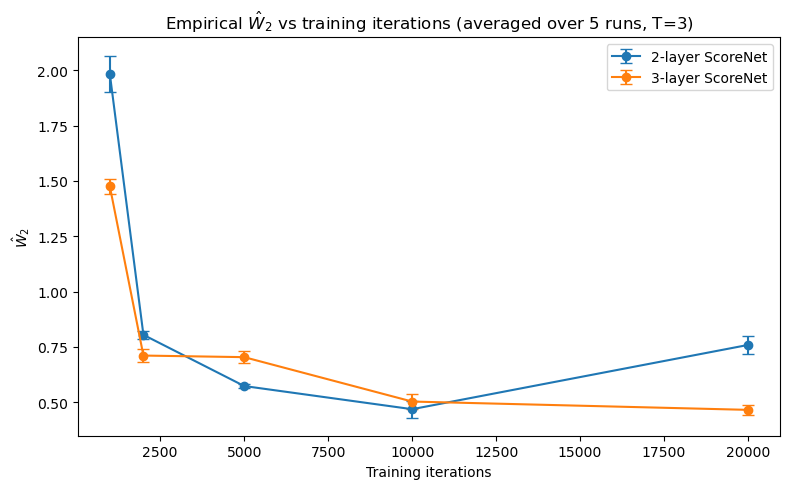

In [ ]:
results_T3 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=3, N_w2= 10_000
)

fct.plot_W2_curve(results_T3, title_suffix="(averaged over 5 runs, T=3)")

Checkpoint 1000...
  W2 2-layer: 0.9384 ± 0.0527 | W2 3-layer: 0.8864 ± 0.0332
Checkpoint 2000...
  W2 2-layer: 0.5107 ± 0.0290 | W2 3-layer: 0.7465 ± 0.0207
Checkpoint 5000...
  W2 2-layer: 0.4782 ± 0.0162 | W2 3-layer: 0.5323 ± 0.0171
Checkpoint 10000...
  W2 2-layer: 0.6625 ± 0.0335 | W2 3-layer: 0.3510 ± 0.0212
Checkpoint 20000...
  W2 2-layer: 0.4327 ± 0.0097 | W2 3-layer: 0.6452 ± 0.0192


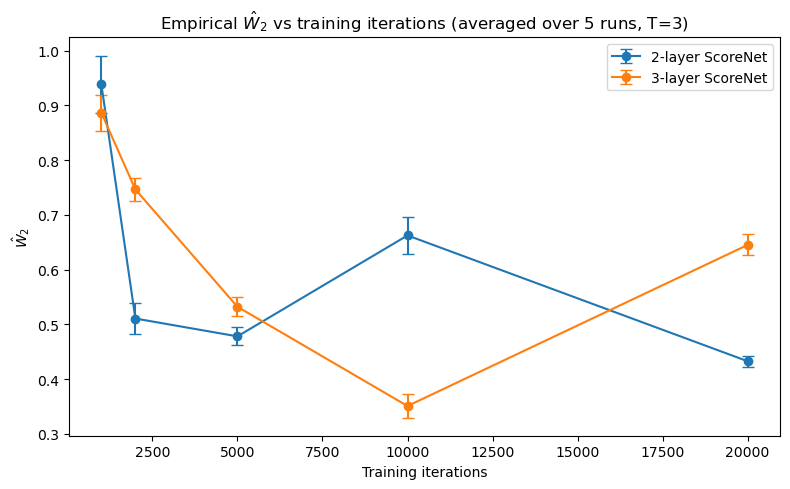

In [ ]:
results_T4 = fct.run_W2_experiment(
    X_data_bimodal, checkpoints, d, device,
    n_repeats=5, T=2, N_w2= 10_000
)

fct.plot_W2_curve(results_T4, title_suffix="(averaged over 5 runs, T=3)")